# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 4 

## EO enhanced benchmarking of GCB DGVMs

**Objective**: SCS4 aims to deepen the understanding of the processes that drive the European land carbon sink, with a focus on productivity, turnover, and the impacts of disturbances and land management. Leveraging new EO data and the [International Land Model Benchmarking (ILAMB)](https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2018MS001354) system, it will assess Dynamic Global Vegetation Models (DGVMs) that contribute to the Global Carbon Budget (GCB) reports. The project will result in an enhanced ILAMB tool, offering insights into carbon dynamics and DGVM performance, and providing a roadmap for future model improvements.

**Outcomes**: An enhanced ILAMB evaluation tool with a focus on internal carbon dynamics and temporal 
change able to provide novel insights into DGVM capabilities to simulate the European land carbon sink and 
identify its main drivers. The spatiotemporal analysis will enable us to produce a roadmap for model 
improvements, in particular regarding forest management.

**Requried datasets**:

* [ESA-CCI Biomass](https://climate.esa.int/en/projects/biomass/)
* [Changes in Global Terrestrial Live Biomass over the 21st Century](https://zenodo.org/records/4161694)
* [GLOBMAP global Leaf Area Index since 1981](https://zenodo.org/records/12698637)
* [FLUXCOM-X-BASE gross primary productivity](https://meta.icos-cp.eu/collections/zfwf1Ak2I7OlziGDTX8Xl6_T)
* [FLUXCOM-X-BASE evapotranspiration](https://meta.icos-cp.eu/collections/zfwf1Ak2I7OlziGDTX8Xl6_T)

-------------------------------------------------------------

## Overview of the Cube Generation Pipeline

This notebook demonstrates how users can access the required datasets via the [xcube Multi-Source Data Store](https://xcube-dev.github.io/xcube-multistore/). All parameters controlling the cube generation workflow are defined in the configuration file [scs4_config.yml](https://github.com/EO-LINCS/eo-lincs-scs4/blob/main/cube_generation/scs4_config.yml).

Comprehensive documentation of the configuration schema is available on the [documentation webpage](https://xcube-dev.github.io/xcube-multistore/config/). A step-by-step example showing how to set up a configuration file—while extracting information from multiple data stores—is provided here:  
[Setup Config YAML File](https://xcube-dev.github.io/xcube-multistore/examples/setup_config/).

In this notebook, we provide:
- A concise preview of the configuration file (summarized in a table)
- The requested geospatial domain
- A walkthrough of the cube generation process

---

### Requirements

Before proceeding, ensure that all required dependencies are installed. The recommended approach is to create a Conda/Mamba environment using the provided environment specification:

`conda env create -f environment.yml`

The corresponding file can be found here: https://github.com/EO-LINCS/eo-lincs-scs2/blob/main/cube_generation/environment.yml

After creation, activate the environment:

`conda activate eo-lincs-scs4`

Next, to access the FLUXCOM-X-BASE data from the [ICOS Data Portal](https://www.icos-cp.eu/data-services/about-data-portal), users must [create an account](https://cpauth.icos-cp.eu/login/?targetUrl=https%3A%2F%2Fwww.icos-cp.eu%2Fdata-services%2Fabout-data-portal) and provide their registered email address and password to the [configuration YAML scs4_config.yml#L71](https://github.com/EO-LINCS/eo-lincs-scs4/blob/main/cube_generation/scs4_config.yml#L71).

---

### Data Preparation

Before running the cube generation workflow, the dataset  **[GLOBMAP Global Leaf Area Index since 1981](https://zenodo.org/records/12698637)** must be prepared.

The individual time slices are accessed via the preload method of xcube’s Zenodo data store. However, constructing a consistent and correct time axis requires additional custom processing. For this reason, the dataset is prepared separately in a dedicated notebook.

In this step, the individual temporal slices are stacked into a single 3D data cube (time, latitude, longitude) with a properly defined time coordinate. This preprocessing is implemented in the notebook [prepare_lai.ipynb](https://github.com/EO-LINCS/eo-lincs-scs4/blob/main/cube_generation/prepare_laiv3.ipynb). For further details, please refer to the notebook.

--- 
### Running the Pipeline

Once all dependencies are installed and the LAI dataset has been prepared, the final data cubes can be generated by executing this notebook.

The results will be stored locally in the final directory, as defined in the configuration YAML file. Initial visualizations of the generated cubes are displayed at the end of the notebook.

---

## Imports 

Let's import everything we need:

In [1]:
import dask
import numpy as np 
from xcube_multistore import MultiSourceDataStore

We suppress the warning `"RuntimeWarning: invalid value encountered in divide"`, which originates from NumPy, by configuring NumPy to ignore floating-point error handling during execution.

In [2]:
np.seterr(divide='ignore', invalid='ignore')
print(np.geterr())

{'divide': 'ignore', 'over': 'warn', 'under': 'ignore', 'invalid': 'ignore'}


We configure Dask to run in a single-threaded mode for two main reasons.

1. It avoid overwhelming the Zenodo API, which introduced stricter rate limits in November 2025 (see [https://blog.zenodo.org/2025/11/25/2025-11-14-search-api-updates/](https://blog.zenodo.org/2025/11/25/2025-11-14-search-api-updates/)). Restricting the cluster to a single worker prevents concurrent requests that could exceed these limits.
2. It ensure safe and deterministic I/O when writing NetCDF files. Without this restriction, we observed warnings and unstable behavior caused by concurrent access to partially written outputs, where multiple tasks may attempt to read from or write to the same file simultaneously. This reflects a known limitation of NetCDF/HDF5-based workflows, where parallel writes are not inherently safe. For this reason, we execute the pipeline sequentially to ensure robustness. Since computational time is not a critical constraint for this SCS, we prioritize stability over performance.

In [3]:
dask.config.set(scheduler="single-threaded")

---
## Configuration of the Cube Generation Process

You can explore the available options for the configuration file using the function `get_config_schema()`. Run it and expand the fields to see all the properties that can be set, in combination with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).  

For guidance on creating your configuration file, you can also refer to the notebook [setup_config.ipynb](../setup_config.ipynb) or consult the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/) in the documentation.

In [4]:
MultiSourceDataStore.get_config_schema()

We can now initialize the `MultiSourceDataStore` by passing the path to the `scs4_config.yml`, which is located in the same directory as this notebook.

Below are a few notes explaining what happens during cube generation:

- The datasets `FLUXCOM-X-BASE_GPP` and `FLUXCOM-X-BASE_ET` are preloaded using the [xcube-icosdp](https://github.com/xcube-dev/xcube-icosdp) package, as these aggregated products are only available via the ICOS Data Portal API. During preloading, the individual time slices are downloaded and combined into a consistent data cube. This step prepares the datasets as described in the xcube-icosdp documentation (see the [aggregated products section in the README](https://github.com/xcube-dev/xcube-icosdp?tab=readme-ov-file#aggregated-products)).

- The `scs4_config.yml` also makes use of the `custom_processing` feature of xcube-multistore. This allows us to apply a custom processing function to each dataset individually. In this example, we define a module called `scs4_modify_dataset`, which contains a function that takes an `xarray.Dataset` as input and returns a modified `xarray.Dataset`. More details about the `custom_processing` option can be found in the [xcube-multistore documentation](https://xcube-dev.github.io/xcube-multistore/config/#custom_processing).

In [5]:
msds = MultiSourceDataStore("scs4_config.yml")

Next, we can display the overview of the configuration file for each dataset.

In [6]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
biomass_xu,zenodo,root: 4161694,test10a_cd_ab_pred_corr_2000_2019_v2.tif,band_as_variable: False,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf
biomass_esa_cci,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.6-0.10000m,-,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf
fluxcom_x_gpp,icosdp,email: <icos-email>; password: <icos-password>,FLUXCOM-X-BASE_GPP_monthly_2000_2021.zarr,-,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf
fluxcom_x_et,icosdp,email: <icos-email>; password: <icos-password>,FLUXCOM-X-BASE_ET_monthly_2000_2021.zarr,-,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf
laiv3,file,root: zenodo_cache/12698637,GlobMapLAIV3.zarr,-,"bbox: [-180, -90, 180, 90]; spatial_res: 0.1; crs: EPSG:4326; tile_size: [1800, 1800]",netcdf


We can display the selected bounding box as shown in the following cell.

In [8]:
msds.display_geolocations()

----
## Cube Generation

Cube generation is triggered with a single command and consists of two stages:

### 1. Preloading

The required datasets from the `icosdp` store are preloaded.  
In this case, the **FLUXCOM-X-BASE** datasets were already available in the local cache, so no additional download was necessary.

### 2. Sequential Processing

After preloading, each dataset is processed sequentially. The following steps are applied as required:

- Spatial resampling to the target grid  
- Temporal aggregation or resampling (e.g., for LAI)  
- Writing the final datacube to the `final/` directory  

### Dataset Notes

- **biomass_xu** Stored as GeoTIFF and accessed lazily. Resampling is performed on the fly before writing the final cube.

- **biomass_esa_cci** Accessed lazily via the xcube ESA CCI datastore, with on-the-fly resampling.

- **fluxcom_x_gpp** and **fluxcom_x_et** Loaded from the local `icosdp` cache (output of the preloading step). User-defined processing specifications are applied during cube generation.

- **laiv3** Prepared in `prepare_laiv3.ipynb`. It requires both spatial resampling and temporal aggregation. As the largest dataset, it has the longest processing time.


> **Note:** Harmless internal HDF5 diagnostic messages are printed to standard output.

In [9]:
%%time
msds.generate()

Data ID,Status,Progress,Message,Exception
FLUXCOM-X-BASE_GPP,COMPLETED,100%,Datacube written to 'FLUXCOM-X-BASE_GPP_monthly_2000_2021.zarr'.,-
FLUXCOM-X-BASE_ET,COMPLETED,100%,Datacube written to 'FLUXCOM-X-BASE_ET_monthly_2000_2021.zarr'.,-


Dataset identifier,Status,Message,Exception
biomass_xu,COMPLETED,Dataset 'biomass_xu' finished: 0:00:46,-
biomass_esa_cci,COMPLETED,Dataset 'biomass_esa_cci' finished: 0:07:52,-
fluxcom_x_gpp,COMPLETED,Dataset 'fluxcom_x_gpp' finished: 0:17:16,-
fluxcom_x_et,COMPLETED,Dataset 'fluxcom_x_et' finished: 0:12:58,-
laiv3,COMPLETED,Dataset 'laiv3' finished: 0:19:52,-


HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 3:
  #000: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /home/conda/feedstock_root/build_artifacts/hdf5_1780922703635/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: /home/conda/feedstock_root/build_artifacts/hdf5_17809227036

CPU times: user 49min 44s, sys: 8min 44s, total: 58min 29s
Wall time: 1h 43min 53s


----

## Initial Inspection of the Generated Datasets

After cube generation has completed, the datasets can be opened using the xcube datastore framework API as usual.

Note that the multi-source datastore expects a datastore named `storage`. This datastore is defined in the `data_stores` section of the `scs4_config.yml` configuration file.

In [10]:
ds = msds.stores.storage.open_data("biomass_xu.nc")
ds

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 20, lat: 1800, lon: 3600)
Coordinates:
  * time            (time) datetime64[ns] 160B 2000-01-01 ... 2019-01-01
  * lat             (lat) float64 14kB 89.95 89.85 89.75 ... -89.85 -89.95
  * lon             (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
    spatial_ref     int64 8B ...
Data variables:
    carbon_density  (time, lat, lon) float64 1GB ...

We select a variable for one timestep and plot it for a quick preview of the data.

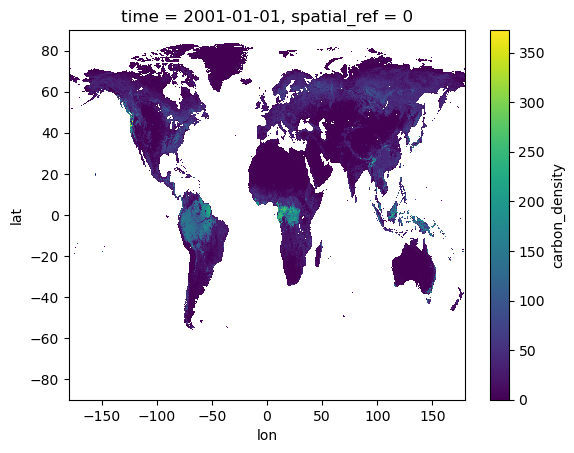

In [11]:
ds.carbon_density.isel(time=1).plot()

The same quicklook can be created for any generated dataset.

In [12]:
ds = msds.stores.storage.open_data("biomass_esa_cci.nc")
ds

<xarray.Dataset> Size: 1GB
Dimensions:      (time: 10, lat: 1800, lon: 3600)
Coordinates:
  * time         (time) datetime64[ns] 80B 2007-07-02 2010-07-02 ... 2022-07-02
  * lat          (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon          (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, lat, lon) float64 518MB ...
    agb_sd       (time, lat, lon) float64 518MB ...
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...
    date_created:            2026-06-15T12:57:58.378955
    processing_level:        L4
    time_coverage_start:     2007-01-01T00:00:00
    time_coverage_end:       2022-12-31T00:00:00
    time_coverage_duration:  P5843DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

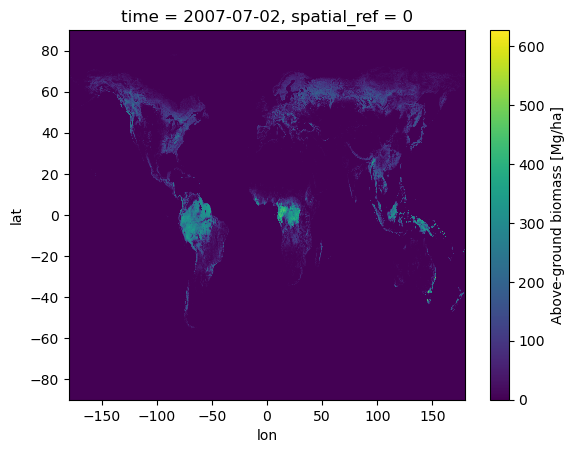

In [13]:
ds.agb.isel(time=0).plot()

In [14]:
ds = msds.stores.storage.open_data("fluxcom_x_gpp.nc")
ds

<xarray.Dataset> Size: 13GB
Dimensions:        (time: 252, lat: 1800, lon: 3600)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2004-01-01 ... 2003-12-01
  * lat            (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon            (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
    spatial_ref    int64 8B ...
Data variables:
    GPP            (time, lat, lon) float64 13GB ...
    land_fraction  (lat, lon) float64 52MB ...
Attributes: (12/29)
    Full_resolution_data:       Visit the dataset documentation at https://gi...
    contact:                    The FLUXCOM-X team, fluxcomx@bgc-jena.mpg.de
    contributor:                ['Jacob Nelson https://orcid.org/0000-0002-46...
    conventions:                CF-1.8
    creation_date:              2023-11-10
    creator:                    The FLUXCOM-X team, fluxcomx@bgc-jena.mpg.de
    ...                         ...
    references:                 
    source:                     ['MODIS Reflectance 10.5067/MODIS/MCD43C2.006...
    summary:                    X-BASE GPP is based on the FLUXCOM-X framewor...
    time_coverage_end:          2021-12-01T00:00:00.000000000
    time_coverage_start:        2001-01-01T00:00:00.000000000
    training_features:          ['TA', 'VPD', 'SW_IN', 'SW_IN_POT', 'dSW_IN_P...

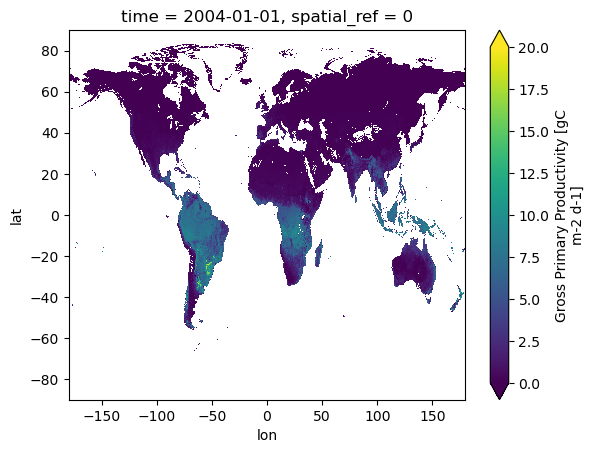

In [15]:
ds.GPP.isel(time=0).plot(vmin=0, vmax=20)

In [16]:
ds = msds.stores.storage.open_data("fluxcom_x_et.nc")
ds

<xarray.Dataset> Size: 13GB
Dimensions:        (time: 252, lat: 1800, lon: 3600)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2020-01-01 ... 2008-12-01
  * lat            (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon            (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
    spatial_ref    int64 8B ...
Data variables:
    ET             (time, lat, lon) float64 13GB ...
    land_fraction  (lat, lon) float64 52MB ...
Attributes: (12/29)
    Full_resolution_data:       Visit the dataset documentation at https://gi...
    contact:                    The FLUXCOM-X team, fluxcomx@bgc-jena.mpg.de
    contributor:                ['Jacob Nelson https://orcid.org/0000-0002-46...
    conventions:                CF-1.8
    creation_date:              2023-11-10
    creator:                    The FLUXCOM-X team, fluxcomx@bgc-jena.mpg.de
    ...                         ...
    references:                 
    source:                     ['MODIS Reflectance 10.5067/MODIS/MCD43C2.006...
    summary:                    X-BASE ET is based on the FLUXCOM-X framework...
    time_coverage_end:          2021-12-01T00:00:00.000000000
    time_coverage_start:        2001-01-01T00:00:00.000000000
    training_features:          ['TA', 'VPD', 'SW_IN', 'SW_IN_POT', 'dSW_IN_P...

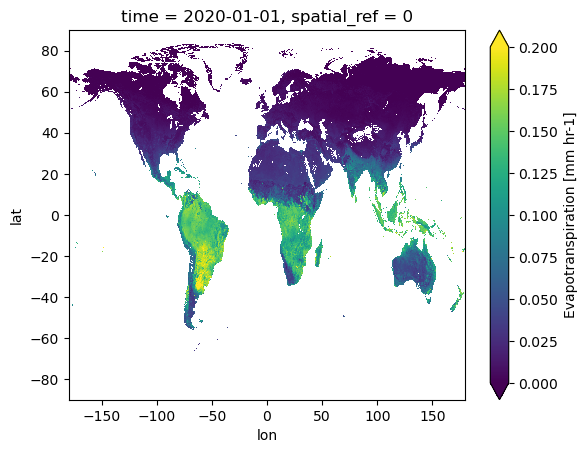

In [17]:
ds.ET.isel(time=0).plot(vmin=0, vmax=0.2)

In [18]:
ds = msds.stores.storage.open_data("laiv3.nc")
ds

<xarray.Dataset> Size: 21GB
Dimensions:      (time: 396, lat: 1800, lon: 3600)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-02-01 ... 2023-12-01
  * lat          (lat) float64 14kB 89.95 89.85 89.75 ... -89.75 -89.85 -89.95
  * lon          (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9
    spatial_ref  int64 8B ...
Data variables:
    lai          (time, lat, lon) float64 21GB ...
Attributes:
    AREA_OR_POINT:        Area
    TIFFTAG_SOFTWARE:     MODISSoft
    time_coverage_start:  1991-01-01T00:00:00
    time_coverage_end:    2023-12-27T00:00:00

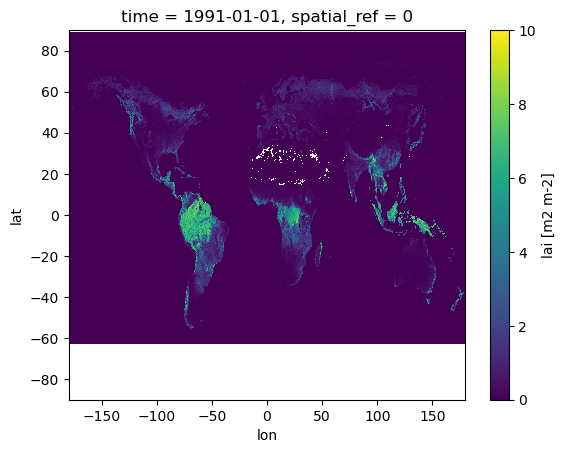

In [19]:
ds.lai.isel(time=0).plot(vmin=0, vmax=10)